Keşifçi Veri Analizi (EDA)

In [2]:
# temel veri işleme kütüphaneleri
import pandas as pd
import numpy as np

# görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

#istatistik kütüphaneleri
from scipy import stats
import warnings

# ayarlar
warnings.filterwarnings('ignore') # uyarı mesajlarını kapatır
pd.set_option('display.max_columns', 50)# büyük veri de gelecek columm sayısını sınırlar
pd.set_option('display.max_rows', None)# satırı sınırlar
pd.set_option('display.float_format', lambda x: '%.2f' % x)#ekranda virgülden sonra kaç basamak

#Grafik stili ayarları
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize']= (12,8)
plt.rcParams['font.size']= 12

print('Tüm kütüphaneler başarıyla yüklendi')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')

print(f'Seaborn version: {sns.__version__}')

Tüm kütüphaneler başarıyla yüklendi
Pandas version: 2.2.2
Numpy version: 2.0.2
Seaborn version: 0.13.2


Veri Yükleme

In [3]:
from google.colab import files
import io

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  # Assuming the uploaded file is a CSV, you can load it into a pandas DataFrame
  # If you have multiple files, you might need to adjust this logic
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
  print(f'DataFrame created from {fn}:')
  display(df.head())
  break # Process only the first uploaded file for simplicity

Saving Cuisine_rating.csv to Cuisine_rating.csv
User uploaded file "Cuisine_rating.csv" with length 17828 bytes
DataFrame created from Cuisine_rating.csv:


,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
0,1,153,"Upper East Side,NY",Female,2006,Single,Professional,3,Japanese,Never,Never,5,4,4.50,No
1,2,123,"St. George,NY",Female,1991,Married,Student,3,Indian,Never,Socially,1,1,1.00,No
2,3,122,"Upper West Side,NY",Male,1977,Single,Student,5,Seafood,Often,Often,5,5,5.00,Yes
3,4,153,"Upper East Side,NY",Female,1956,Married,Professional,5,Japanese,Never,Socially,3,1,2.00,No
4,5,129,"Central Park,NY",Male,1997,Single,Student,4,Filipino,Socially,Never,2,4,3.00,No


In [ ]:
df.head()

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
0,1,153,"Upper East Side,NY",Female,2006,Single,Professional,3,Japanese,Never,Never,5,4,4.50,No
1,2,123,"St. George,NY",Female,1991,Married,Student,3,Indian,Never,Socially,1,1,1.00,No
2,3,122,"Upper West Side,NY",Male,1977,Single,Student,5,Seafood,Often,Often,5,5,5.00,Yes
3,4,153,"Upper East Side,NY",Female,1956,Married,Professional,5,Japanese,Never,Socially,3,1,2.00,No
4,5,129,"Central Park,NY",Male,1997,Single,Student,4,Filipino,Socially,Never,2,4,3.00,No


In [ ]:
df.tail()

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
195,196,175,"St. George,NY",Female,1982,Single,Professional,4,French,Never,Socially,1,2,1.50,No
196,197,170,"Upper West Side,NY",Female,2000,Married,Student,4,Chinese,Never,Often,1,2,1.50,No
197,198,160,"St. George,NY",Female,2006,Single,Professional,5,Japanese,Never,Often,5,2,3.50,No
198,199,130,"St. George,NY",Male,2002,Married,Student,3,Filipino,Never,Socially,3,2,2.50,No
199,200,140,"Upper East Side,NY",Male,2005,Married,Student,4,French,Never,Never,3,2,2.50,No


In [ ]:
df.sample(5)

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
196,197,170,"Upper West Side,NY",Female,2000,Married,Student,4,Chinese,Never,Often,1,2,1.50,No
28,29,154,"Market City, NY",Female,1977,Married,Student,4,French,Socially,Never,2,1,1.50,No
92,93,123,"St. George,NY",Male,2000,Single,Professional,5,French,Never,Often,5,5,5.00,No
52,53,153,"Upper East Side,NY",Female,1974,Single,Professional,4,Chinese,Never,Often,3,5,4.00,No
145,146,102,"China Town, NY",Male,1976,Married,Student,3,Chinese,Never,Never,2,5,3.50,No


In [4]:
print('Veri tipleri')
print('='*40)
dtype_df= pd.DataFrame({
    'sütun': df.columns,
    'veri tipi': df.dtypes.values,
    'null değeri':df.isnull().sum().values,
    'null oranı(%)': (df.isnull().sum().values/len(df)*100).round(2),
    'unıque': df.nunique().values
})

print(dtype_df.to_string(index=False))

Veri tipleri
         sütun veri tipi  null değeri  null oranı(%)  unıque
       User ID     int64            0           0.00     200
     Area code     int64            0           0.00      65
      Location    object            0           0.00      10
        Gender    object            0           0.00       2
           YOB     int64            0           0.00      46
Marital Status    object            0           0.00       3
      Activity    object            0           0.00       2
        Budget     int64            0           0.00       5
      Cuisines    object            0           0.00       7
      Alcohol     object            0           0.00       3
        Smoker    object            0           0.00       3
   Food Rating     int64            0           0.00       5
Service Rating     int64            0           0.00       5
Overall Rating   float64            0           0.00       9
     Often A S    object            0           0.00       2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   User ID         200 non-null    int64  
 1   Area code       200 non-null    int64  
 2   Location        200 non-null    object 
 3   Gender          200 non-null    object 
 4   YOB             200 non-null    int64  
 5   Marital Status  200 non-null    object 
 6   Activity        200 non-null    object 
 7   Budget          200 non-null    int64  
 8   Cuisines        200 non-null    object 
 9   Alcohol         200 non-null    object 
 10  Smoker          200 non-null    object 
 11  Food Rating     200 non-null    int64  
 12  Service Rating  200 non-null    int64  
 13  Overall Rating  200 non-null    float64
 14  Often A S       200 non-null    object 
dtypes: float64(1), int64(6), object(8)
memory usage: 23.6+ KB


In [6]:
df.shape

(200, 15)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
User ID,200.00,100.50,57.88,1.00,50.75,100.50,150.25,200.00
Area code,200.00,141.06,26.13,101.00,123.00,135.00,158.00,199.00
YOB,200.00,1984.83,16.81,1955.00,1971.00,1987.00,2000.00,2009.00
Budget,200.00,3.81,1.06,1.00,3.00,4.00,5.00,5.00
Food Rating,200.00,3.22,1.41,1.00,2.00,3.00,5.00,5.00
Service Rating,200.00,3.23,1.53,1.00,2.00,3.00,5.00,5.00
Overall Rating,200.00,3.23,1.08,1.00,2.50,3.00,4.00,5.00


In [8]:
df.describe(include='object').T

,count,unique,top,freq
Location,200,10,"St. George,NY",46
Gender,200,2,Male,118
Marital Status,200,3,Single,100
Activity,200,2,Student,120
Cuisines,200,7,Japanese,36
Alcohol,200,3,Never,88
Smoker,200,3,Socially,71
Often A S,200,2,No,174


In [9]:
#Eksik veri kontorlü
eksik=df.isnull().sum()
print(eksik)

User ID           0
Area code         0
Location          0
Gender            0
YOB               0
Marital Status    0
Activity          0
Budget            0
Cuisines          0
Alcohol           0
Smoker            0
Food Rating       0
Service Rating    0
Overall Rating    0
Often A S         0
dtype: int64


Eksik veri olmadığı için analiz kısmına geçiyoruz

Tek değişkenli analiz

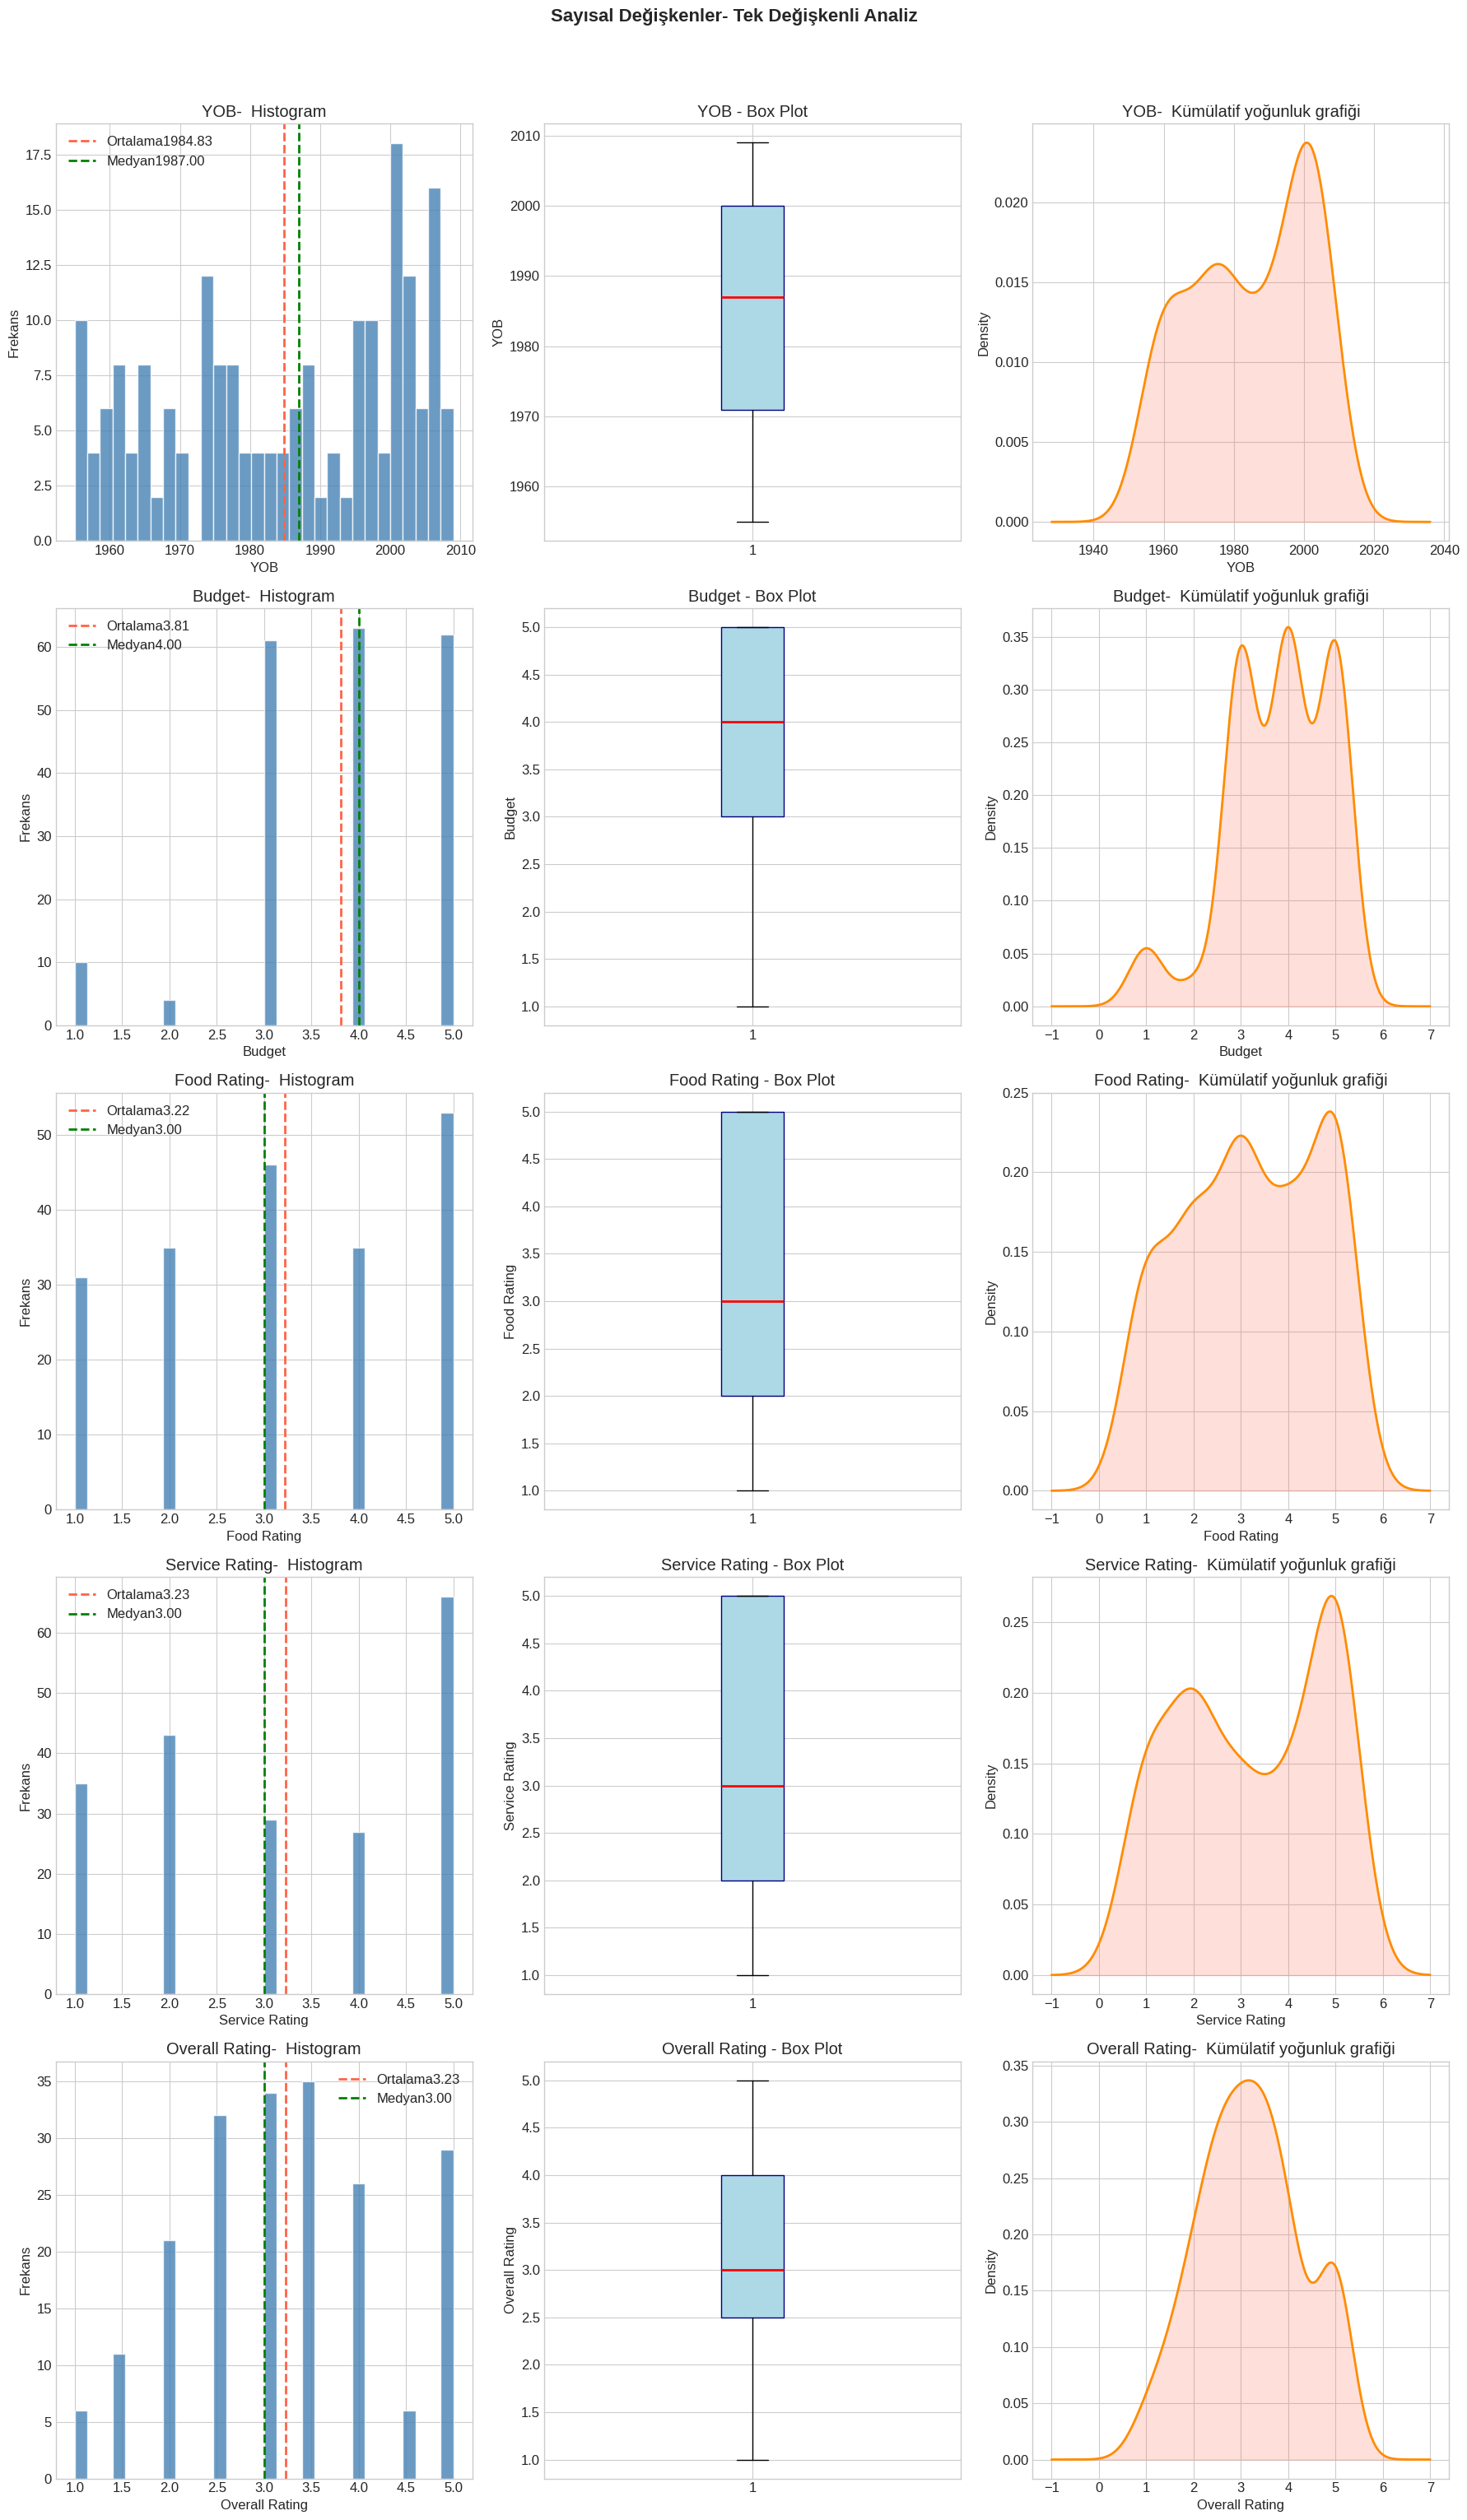

In [10]:
sayisal_kolonlar=['YOB','Budget','Food Rating','Service Rating','Overall Rating']

fig, axes = plt.subplots(len(sayisal_kolonlar), 3 , figsize=(18, 6*len(sayisal_kolonlar)))

for i, kolon in enumerate(sayisal_kolonlar):
  veri = df[kolon]

  axes[i,0].hist(veri, bins=30, color='steelblue',edgecolor='white',alpha=0.8)
  axes[i,0].axvline(veri.mean(), color='tomato', linestyle='dashed', linewidth=2, label=f'Ortalama{veri.mean():.2f}')
  axes[i,0].axvline(veri.median(), color='green', linestyle='dashed', linewidth=2, label=f'Medyan{veri.median():.2f}')
  axes[i,0].set_title(f'{kolon}-  Histogram')
  axes[i,0].legend()
  axes[i,0].set_xlabel(kolon)
  axes[i,0].set_ylabel('Frekans')

      # Box plot
  axes[i, 1].boxplot(veri, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'),
                       medianprops=dict(color='red', linewidth=2))
  axes[i, 1].set_title(f'{kolon} - Box Plot')
  axes[i, 1].set_ylabel(kolon)


  veri.plot.kde(ax=axes[i,2],color='darkorange',linewidth=2)
  axes[i,2].fill_between(axes[i,2].lines[0].get_xdata(),
                        axes[i,2].lines[0].get_ydata(),
                        color='tomato',alpha=0.2)
  axes[i,2].set_title(f'{kolon}-  Kümülatif yoğunluk grafiği')
  axes[i,2].set_xlabel(kolon)


plt.suptitle('Sayısal Değişkenler- Tek Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# istatiksel özet tablo
print('Sayısal Değişkenler detaylı İstatistikler:')
print('='*70)


for kolon in sayisal_kolonlar :
  veri=df[kolon].dropna()
  print(f'\n * {kolon.upper()}')
  print(f'Ortalama: {veri.mean():.2f}')
  print(f'Medyan: {veri.median():.2f}')
  print(f'Standart Sapma: {veri.std():.2f}')
  print(f'Minimum: {veri.min():.2f}')
  print(f'Maksimum: {veri.max():.2f}')
  print(f'Varyans: {veri.var():.2f}')
  print(f'Skewness(Çarpıklık): {veri.skew():.2f}')
  print(f'Kurtosis(Basıklık): {veri.kurtosis():.2f}')
  print(f'IQR: {veri.quantile(0.75)-veri.quantile(0.25):.2f}')
  print('='*70)

Sayısal Değişkenler detaylı İstatistikler:

 * YOB
Ortalama: 1984.83
Medyan: 1987.00
Standart Sapma: 16.81
Minimum: 1955.00
Maksimum: 2009.00
Varyans: 282.55
Skewness(Çarpıklık): -0.25
Kurtosis(Basıklık): -1.29
IQR: 29.00

 * BUDGET
Ortalama: 3.81
Medyan: 4.00
Standart Sapma: 1.06
Minimum: 1.00
Maksimum: 5.00
Varyans: 1.12
Skewness(Çarpıklık): -0.76
Kurtosis(Basıklık): 0.36
IQR: 2.00

 * FOOD RATING
Ortalama: 3.22
Medyan: 3.00
Standart Sapma: 1.41
Minimum: 1.00
Maksimum: 5.00
Varyans: 1.99
Skewness(Çarpıklık): -0.16
Kurtosis(Basıklık): -1.25
IQR: 3.00

 * SERVICE RATING
Ortalama: 3.23
Medyan: 3.00
Standart Sapma: 1.53
Minimum: 1.00
Maksimum: 5.00
Varyans: 2.33
Skewness(Çarpıklık): -0.13
Kurtosis(Basıklık): -1.50
IQR: 3.00

 * OVERALL RATING
Ortalama: 3.23
Medyan: 3.00
Standart Sapma: 1.08
Minimum: 1.00
Maksimum: 5.00
Varyans: 1.17
Skewness(Çarpıklık): 0.06
Kurtosis(Basıklık): -0.70
IQR: 1.50
